# SF boundaries

The regional boundaries everything else in this project joins onto: the city land
boundary, the 11 (post-2022) supervisor districts, the 41 Analysis Neighborhoods,
and 2020 census tracts.

Data comes through `sfdata.fetch`, which downloads any dataset registered in
`datasets.yaml` and caches it under `data/raw/`. Run
`uv run scripts/fetch_boundaries.py` once first (or just call `fetch.load` — it
downloads on demand).

In [1]:
import matplotlib.pyplot as plt

from sfdata import fetch

city = fetch.load("city_boundary")
districts = fetch.load("supervisor_districts")
neighborhoods = fetch.load("analysis_neighborhoods")
tracts = fetch.load("census_tracts")

len(city), len(districts), len(neighborhoods), len(tracts)

(1, 11, 41, 244)

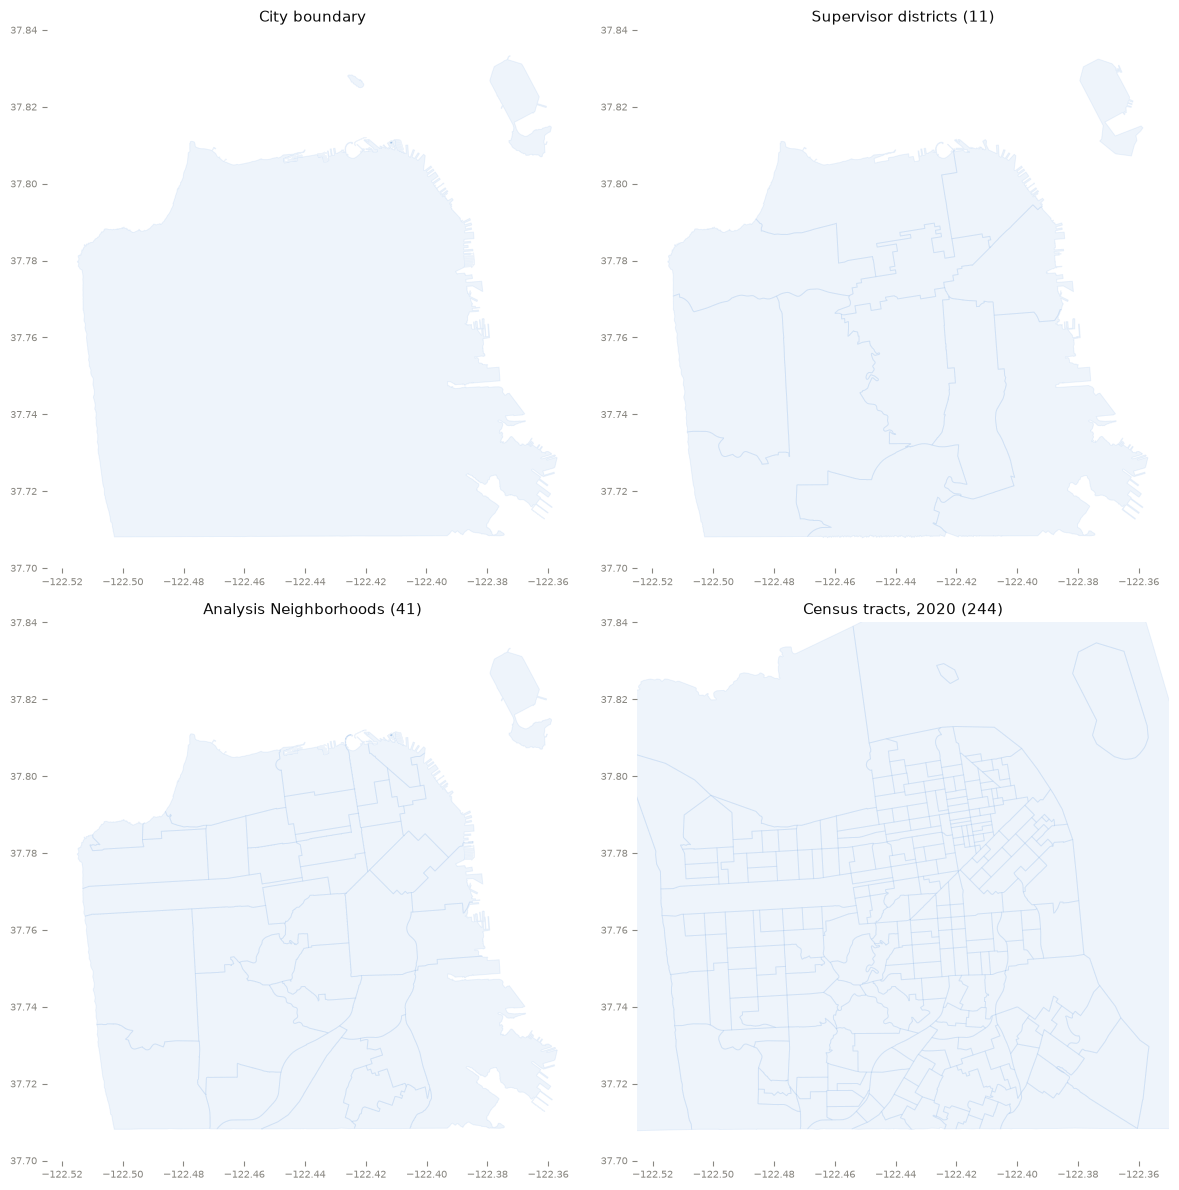

In [2]:
BLUE, INK, MUTED = "#2a78d6", "#0b0b0b", "#898781"

# The Farallon Islands are part of the city (and of District 4 and one census
# tract), 30 mi offshore — crop to the peninsula so the maps are readable.
PENINSULA = dict(xlim=(-122.525, -122.35), ylim=(37.70, 37.84))

fig, axes = plt.subplots(2, 2, figsize=(12, 12))
layers = [
    (city, "City boundary"),
    (districts, "Supervisor districts (11)"),
    (neighborhoods, "Analysis Neighborhoods (41)"),
    (tracts, "Census tracts, 2020 (244)"),
]
for ax, (gdf, title) in zip(axes.flat, layers):
    gdf.plot(ax=ax, facecolor=BLUE, alpha=0.08, edgecolor=BLUE, linewidth=0.7)
    ax.set(**PENINSULA)
    ax.set_title(title, color=INK, fontsize=11)
    ax.tick_params(colors=MUTED, labelsize=7)
    for s in ax.spines.values():
        s.set_visible(False)
fig.tight_layout()

## Interactive exploration

`GeoDataFrame.explore()` gives a pan/zoom Leaflet map — hover a district to see
who represents it.

In [3]:
districts[["sup_dist", "sup_name", "geometry"]].explore(
    color=BLUE, style_kwds={"fillOpacity": 0.08, "weight": 1.5}, tiles="CartoDB positron"
)

## Tract → neighborhood crosswalk

Lots of DataSF data keys to census tracts; this crosswalk rolls tracts up to
Analysis Neighborhoods without a spatial join.

In [4]:
xwalk = fetch.load("tracts_to_neighborhoods")
xwalk.head()

,the_geom,object_id,state_fp,county_fp,tractce,name,neighborhoods_analysis_boundaries,data_loaded_at,sup_dist_2012,sup_dist_2022,data_as_of,geoid
0,MULTIPOLYGON (((-122.37276211607421 37.7455051...,242,6,75,980900,9809.00,Bayview Hunters Point,2022-07-08T14:12:00.000,10,10,2022-07-08T21:09:48.141,6075980900
1,MULTIPOLYGON (((-122.36519199065519 37.7337298...,241,6,75,980600,9806.00,Bayview Hunters Point,2022-07-08T14:12:00.000,10,10,2022-07-08T21:09:48.141,6075980600
2,MULTIPOLYGON (((-122.40666500014143 37.7192149...,240,6,75,980501,9805.01,McLaren Park,2022-07-08T14:12:00.000,10,10,2022-07-08T21:09:48.141,6075980501
3,MULTIPOLYGON (((-123.00359900126116 37.6932479...,239,6,75,980401,9804.01,The Farallones,2022-07-08T14:12:00.000,1,4,2022-07-08T21:09:48.141,6075980401
4,MULTIPOLYGON (((-122.38528200051307 37.7402399...,226,6,75,61200,612.00,Bayview Hunters Point,2022-07-08T14:12:00.000,10,10,2022-07-08T21:09:48.141,6075061200
